# Reinforcement Learning In PyWorld3-03 With Some Control Functions

**Authors of this modified file:** Evelina Örsvik and Linnea Stålberg

**Date of modifications:** March-May 2026

**Note on original authors:** This file is an adaptation of Emil Johansson and Linnéa Bäckvall's reinforcement learning file `reinforcementLearning.ipynb` available at https://github.com/emilj610/pyworld3A3. It has been modified to fit our (the authors') purposes.

*We have also referred to lecture notes in the KTH course DD1420 as well as documentation of relevant libraries, [PyTorch beginner tutorials](https://docs.pytorch.org/tutorials/beginner/basics/intro.html), World3 literature and the bachelor thesis report of Emil Johansson and Linnéa Bäckvall.*

The goal is to train a neural network to approximate a cumulative reward function $J$ with the approximation $\hat J$. Then we try to find better controls than used for the standard run (using $\hat J$ as the objective function to optimise) by doing a grid search.

Running this file successfully requires having training data first. Training data can be obtained by running `data_generation.py`.

The disposition of the file is the following:

1.  Initial setup
2.  Data extraction and training of neural network
3.  Optimization
4.  Plot results

## Initial setup

Import libraries, define some constants, initialise a standard run of World3-03, and define reward function(s).

In [1]:
# Imports

# General, used throughout the file
import numpy as np
from pyworld3 import World3
from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm # used for progress bar

# For nn training
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# To save data between runs
import json
import os
import pickle # to save StandardScalers # https://stackoverflow.com/questions/10592605/save-classifier-to-disk-in-scikit-learn, https://scikit-learn.org/stable/model_persistence.html, https://docs.python.org/3/library/pickle.html

# Specials
from pyworld3.utils import plot_world_variables, standard_setup
from rewards import *
from control_maps_and_loops import *

In [2]:
# Define constants to be used throughout the file
MIN_YEAR = 1900
MAX_YEAR = 2100
FAST = True # select, for runs where it is safe, whether to run with fast=True or fast=False; fast=False is always used for some runs
NOISE = True

# Used to load existing NN model if wished
# This NN model will replace the one trained in this file unless LOAD_NN_TRAIN_ID = None or LOAD_NN_RL_ID = None
# If NN model is loaded it is not saved anew. Let SAVE_RESULTS = True and LOAD_NN_TRAIN_ID = None or LOAD_NN_RL_ID = None to save the model that is trained.
LOAD_NN_TRAIN_ID = "33" # train ID of NN model to load, set to None if you do not wish to load existing NN model
LOAD_NN_RL_ID = "33" # RL ID of NN model to load, set to None if you do not wish to load existing NN model

In [3]:
# Standard run until MAX_YEAR
world_reference = World3(year_min=MIN_YEAR, year_max=MAX_YEAR, noise=NOISE)
standard_setup(world_reference)
world_reference.run_world3(fast=False) # use fast=False here for extra safety

STD_SEED = world_reference.seed

Here we define the Human Welfare Index (built into World3-03) as the reward function, $g$. Most likely we will also define other reward functions in the future.

In [4]:
def reward_HSDI(world, k=None):
    return reward_HSDI_ref(world, world_reference, k)

## Data extraction and training of neural network

In this section we extract the data from its storage, preprocess it, and use it to train a neural network. We also plot the loss. The disposition of this section is as follows:

1.  Data extraction and setup
2.  Preprocessing
3.  Training and creating a function
4.  Loss comparison

### Data extraction and setup

Running this requires a file with training data. Training data should include cumulative rewards $J$ (throughout each run) and state variables (throughout each run) stored for runs with randomised initial values.

In [5]:
reward_dict = {"HSDI" : reward_HSDI,
               "HWI" : reward_hwi,
               "doughnut" : reward_doughnut}

reward_name = "doughnut"
reward_func = reward_dict[reward_name]

IN_ID = "33"  # data from data generation

reward_func_name = reward_func.__name__
filepath = f"datasets/traintest/{reward_name}/{IN_ID}_data_{reward_name}.parquet"

df = pd.read_parquet(filepath)
STATE_VARIABLES = df.columns[df.columns != "J"]
no_init_vars = ["time"] # specify which variables are not "initialable"

Define a neural network class (requires imports from PyTorch and scikit-learn, imported in the beginning of this file). Use two hidden layers and ReLU activation ($\text{act}(z)=\max(0, z)$) throughout the forward pass. Note that `nn.Module` is a base class that our class `neuralNet` builds upon.

In [6]:
class neuralNet(nn.Module):
    def __init__(self, in_dim, out_dim):
        # 2 hidden layers
        super(neuralNet, self).__init__()
        self.input_layer = nn.Linear(in_features=in_dim, out_features=32)
        self.hidden_layer1 = nn.Linear(in_features=32, out_features=64)
        self.hidden_layer2 = nn.Linear(in_features=64, out_features=32)
        self.outLayer = nn.Linear(in_features=32, out_features=out_dim)

    def forward(self, x):
        # forward pass with relu activation function
        x = self.input_layer(x)
        x = torch.relu(self.hidden_layer1(x))
        x = torch.relu(self.hidden_layer2(x))
        x = self.outLayer(x)
        return x

### Preprocessing

Here we preprocess the data before feeding it to our neural network.

We split the data so that 80% is used for training and 20% for testing. One can change these proportions by modifying `test_size` in `train_test_split` call. Selecting `random_state=42` allows us to reproduce results across multiple function calls. For further information see the documentation of `sklearn.model_selection.train_test_split`.

We also normalise the data to increase stability and speed of the neural network.
For $X$ (i.e., state variables) and $J$ (i.e., true reward) separately, we fit a `StandardScaler` to the training data, then transform the data using the mean and standard deviation obtained during fitting. Then we also transform the training data with the same mean and standard deviation (separately for $X$ and $J$).

After normalising the data, we turn it into PyTorch tensors (similar to ndarrays in NumPy).

In [7]:
X = df.drop(columns=["J"]).to_numpy()
J = df["J"].to_numpy().reshape(-1,1)

X_train, X_test, J_train, J_test = train_test_split(X, J, test_size=0.2, random_state=42) # change test_size for different proportion of training/testing data

# normalising
X_normaliser = StandardScaler()
X_train = X_normaliser.fit_transform(X_train)
X_test = X_normaliser.transform(X_test)
J_normaliser = StandardScaler()
J_train = J_normaliser.fit_transform(J_train)
J_test = J_normaliser.transform(J_test)

# turning into pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
J_train = torch.tensor(J_train, dtype=torch.float32)
J_test = torch.tensor(J_test, dtype=torch.float32)

Now `X_train` is a PyTorch tensor with each datapoint stored as a row. So the dimension of one datapoint is `X_train.shape[1]` (number of columns in `X_train`).

### Training and creating a function

Here we create a neural network model using mean squared error (MSE) loss. As an optimiser we use Adam (Adaptive Moment Estimation) built into PyTorch. Further, we use the learning rate 0.001. For details please see the `torch.optim.Adam` documentation and PyTorch tutorials, in particular https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html. We train the NN using the runs (without control functions) with randomised initial state variables (randomised with Gaussian distribution around standard run initial values) that our training data set consists of. The NN is trained to represent the approximative cumulative reward, $\hat J$.

In [8]:
def reg_loss_func(X_pred, X_true):
    pass


model = neuralNet(X_train.shape[1], 1)

loss_func = nn.MSELoss()
optimiser = torch.optim.Adam(model.parameters(), lr=0.001) # the method with which the NN optimises the loss function

epochs = 200
losses = np.zeros((epochs,1)) # storage for training losses
test_losses = np.zeros((epochs,1)) # storage for test losses


for epoch in tqdm(range(epochs)):
    model.train() # activate training mode (best practice)

    # Prediction and loss
    J_pred = model.forward(X_train)
    loss = loss_func(J_pred, J_train) # J_train is the true value, J_pred is the predicted value

    # Backpropagation
    optimiser.zero_grad() 
    loss.backward() 
    optimiser.step() 
    losses[epoch] = loss.item() # save training loss

    model.eval() # activate evaluation mode (best practice)
    with torch.no_grad():
        J_pred_test = model.forward(X_test)
        loss_test = loss_func(J_pred_test, J_test)
        test_losses[epoch] = loss_test # save test loss

100%|██████████| 200/200 [00:54<00:00,  3.66it/s]


Plot the training and test losses.

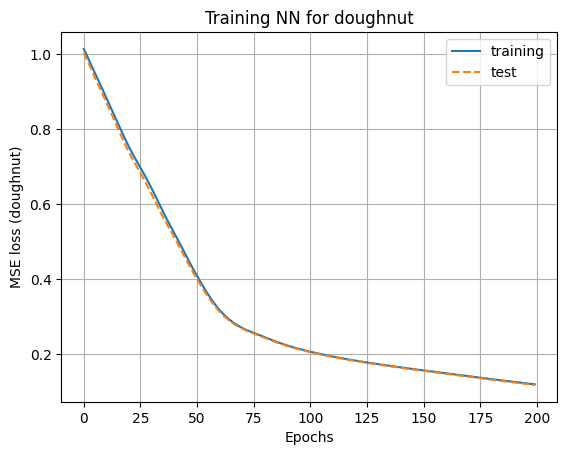

In [9]:
plt.plot(losses, label="training")
plt.plot(test_losses, label="test", linestyle='--')

plt.xlabel("Epochs")
plt.ylabel(f"MSE loss ({reward_name})")
plt.title(f"Training NN for {reward_name}")
plt.legend(), plt.grid(), 
if LOAD_NN_TRAIN_ID!=None and LOAD_NN_RL_ID!=None:
    plt.savefig(f"plots/{reward_name}/training")
plt.show()

### Loss comparison

In [10]:
X_numpy = X_normaliser.inverse_transform(X_test.numpy())
J_numpy = J_test.numpy()

time_index = STATE_VARIABLES.get_loc('time')
errors = []
years = []

for year in range(MIN_YEAR, MAX_YEAR, 5):
    condition = (X_numpy[:, time_index] < year+5) & (X_numpy[:, time_index] >= year)  # all rows where the condition is true
    row_indices = np.where(condition)[0]

    X_rows =  X_normaliser.transform(X_numpy[row_indices,:])

    model.eval()
    with torch.no_grad():
        J_pred = model.forward(torch.tensor(X_rows, dtype=torch.float32))
    error = np.sum((J_pred.numpy() - J_numpy[row_indices])**2) / row_indices.size
    errors.append(error)
    years.append(year)

Plot the results.

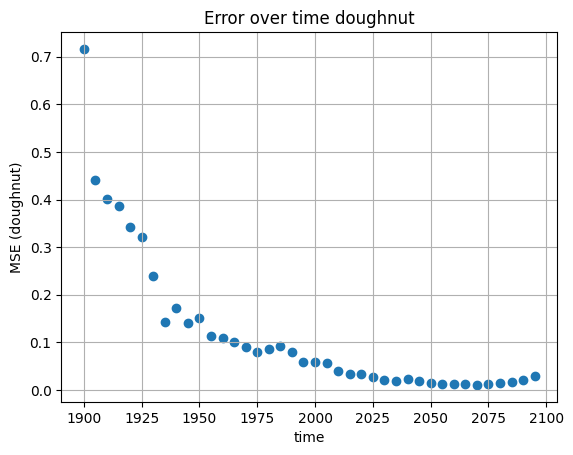

In [11]:
plt.scatter(years, errors)
plt.xlabel("time")
plt.ylabel(f"MSE ({reward_name})")
plt.title(f"Error over time {reward_name}")
plt.grid()
if LOAD_NN_TRAIN_ID!=None and LOAD_NN_RL_ID!=None:
    plt.savefig(f"plots/{reward_name}/time_error")
plt.show()

### Load model (optional)

In [12]:
def load_model(train_id=LOAD_NN_TRAIN_ID, rl_id=LOAD_NN_RL_ID):

    # Step 1: Load in_dim = X_train.shape[1]
    indim_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_addinf_nn.json"
    json_file = os.path.join(os.getcwd(), indim_path)
    with open(json_file) as fjson:
        table = json.load(fjson)[0]
    in_dim = table["nn_in_dim"]

    # Step 2: Load X_normaliser and J_normaliser
    x_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_xnormaliser.pkl"
    with open(x_path, 'rb') as fid:
        X_normaliser = pickle.load(fid)
    j_path = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_jnormaliser.pkl"
    with open(j_path, 'rb') as fid:
        J_normaliser = pickle.load(fid)

    # Step 3: Load NN model
    modelpath = f"datasets/ctrl_results/{reward_name}/train{train_id}_rl{rl_id}_model.pt"
    model = neuralNet(in_dim, 1) # corresponds to model = neuralNet(X_train.shape[1], 1)
    model.load_state_dict(torch.load(modelpath, weights_only=True))
    model.eval()
    
    return model, X_normaliser, J_normaliser

In [13]:
if LOAD_NN_TRAIN_ID!=None and LOAD_NN_RL_ID!=None:
    model, X_normaliser, J_normaliser = load_model()

### Define $\hat J$ function

In the following cell we define a function to approximate the cumulative reward function.

In [14]:
def nn_func(model, world, k):
    """ 
    In:
        model: neural network model
        world: World3 object
        k: current iteration
    Returns:
        J_hat
    
    Approximate the cumulative reward function
    """
    model.eval() # activate evaluation mode (best practice)
    state = np.array([getattr(world, var)[k] for var in STATE_VARIABLES]) # find current state
    state = X_normaliser.transform(state.reshape(1, -1)) # normalise current state
    state = torch.tensor(state, dtype=torch.float32) # transform into a PyTorch tensor
    with torch.no_grad():
        J_ = J_normaliser.inverse_transform(model.forward(state))
    return J_.item()

## Optimization

Choose number of control functions (1 or 2) and which control function(s).

In [15]:
CONTROL_NAMES = ["DCFSN", "ISOPC"] # choose control funcs (1 or 2)
NUM_CTRL_FUNCS = len(CONTROL_NAMES)

Define number of values to use for each value in the grid search.

In [16]:
GRID_SZ_1 = 15 # select 5 for much faster code, but 15 as default for better results
GRID_SZ_2 = 15 # this value is not used if only one control function is used

LOOKAHEAD = 20

Define functions that will be used.

In [17]:
def generate_fioac_control_values(world3, k, grid_sz=15):
    """
    In:
        world3  - World3 object
        k       - int: the time step for which to generate control values
        grid_sz - int: number of control values to generate
    Out:
        numpy array of grid_sz evenly spaced values between lower bound and upper bound

    Generate control values to use/try for fioac at time step k
    """
    current_value = world3.fioac_control(k-1) # fioac control value at time step k-1
    max_dev = 0.3 # allow the new fioac control value (at k) to deviate at most 0.3 from the previous value (at k-1)
    lower_bound = max(current_value - max_dev, 0)   # Ensure the minimum value is at least 0, since fioac is a fraction
    upper_bound = min(current_value + max_dev, 1)   # Ensure that the maximum value is at most 1, since fioac is a fraction
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_isopc_control_values(world3, k, grid_sz=15):
    """
    In:
        world3  - World3 object
        k       - int: the time step for which to generate control values
        grid_sz - int: number of control values to generate
    Out:
        numpy array of grid_sz evenly spaced values between lower bound and upper bound
    
    Generate control values to use/try for isopc at time step k
    """
    current_value = world3.isopc_control(k-1)
    max_dev = 0.4 # allow the new isopc control value (at k) to deviate at most 0.4 from previous value (at k-1)
    lower_bound = max(current_value - max_dev, 0.01)   # Ensure the minimum value is at least 0.01 to avoid div with zero
    upper_bound = min(current_value + max_dev, 2)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_dcfsn_control_values(world3, k, grid_sz=15, max_dev=1.0, up_max=10, lo_min=1.0):
    current_value = world3.dcfsn_control(k-1)
    # TODO: change max_dev and up_max to suitable values
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_iopc_control_values(world3, k, grid_sz=15, max_dev=0.4, up_max=2.0, lo_min=0.1):
    current_value = world3.iopc_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_alic_control_values(world3, k, grid_sz=15, max_dev=3, up_max=30.0, lo_min=0.1):
    current_value = world3.alic_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_fioaa_control_values(world3, k, grid_sz=15, max_dev=0.3, up_max=1.0, lo_min=0):
    current_value = world3.fioaa_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_dppolx_control_values(world3, k, grid_sz=15, max_dev=0.4, up_max=3.0, lo_min=0):
    current_value = world3.dppolx_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_fioai_control_values(world3, k, grid_sz=15, max_dev=0.3, up_max=1.0, lo_min=0):
    current_value = world3.fioai_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_ppgf_control_values(world3, k, grid_sz=15, max_dev=0.3, up_max=2.0, lo_min=0):
    current_value = world3.fioai_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)

def generate_fioas_control_values(world3, k, grid_sz=15, max_dev=0.3, up_max=1.0, lo_min=0):
    current_value = world3.fioas_control(k-1)
    lower_bound = max(current_value - max_dev, lo_min)
    upper_bound = min(current_value + max_dev, up_max)
    return np.linspace(lower_bound, upper_bound, grid_sz)


def generate_control_values(control_name, world3, k, grid_sz):
    if control_name=="FIOAC":
        return generate_fioac_control_values(world3, k, grid_sz)
    elif control_name=="ISOPC":
        return generate_isopc_control_values(world3, k, grid_sz)
    elif control_name=="DCFSN":
        return generate_dcfsn_control_values(world3, k, grid_sz)
    elif control_name=="IOPC":
        return generate_iopc_control_values(world3, k, grid_sz)
    elif control_name=="ALIC":
        return generate_alic_control_values(world3, k, grid_sz)
    elif control_name=="FIOAA":
        return generate_fioaa_control_values(world3, k, grid_sz)
    elif control_name=="DPPOLX":
        return generate_dppolx_control_values(world3, k, grid_sz)
    elif control_name=="FIOAI":
        return generate_fioai_control_values(world3, k, grid_sz)
    elif control_name=="PPGF":
        return generate_ppgf_control_values(world3, k, grid_sz)
    elif control_name=="FIOAS":
        return generate_fioas_control_values(world3, k, grid_sz)


def estimate_cumulative_reward(k, steps, fast, world3, J_hat):
    reward = 0
    for k_new in range(k,k+steps):
        # Calculate cumulative reward from step k and `steps` steps into the future
        if fast:
            world3._loopk_world3_fast(k_new-1, k_new, k_new-1, k_new)
        else:
            loopk(world3, k_new)
        if k_new != k+steps-1:
            reward += reward_func(world3, k_new) # note that reward_func is the actual reward function (not an approximation)
        else: # last step
            J_val = J_hat(world3, k_new) # J_hat is the approximation of the cumulative reward function
            reward += J_val # capture future (without control)
    return reward

def get_control(world3, k, steps, J_hat, ctrl1_name, ctrl1_grid_sz=15, ctrl2_name=None, ctrl2_grid_sz=15, fast=False):
    """ 
    In:
        world3: pyworld3 simulation
        k: current iteration
        steps: how many steps to look ahead
        J_hat: Approximation of J function
        fast: selects which version of world3 to run (when feasible)
    Returns:
        control: fioac control value, isopc control value

    Note: here we assume we wish to maximise the cumulative reward J.
    It is appropriate for a reward function like HWI, where a large value is desired.
    For other parameters, such as ecological footprint (EF), we wish to minimise them.
    So in those cases it is important to still formulate the reward function so that
    a large value of the reward is desired, e.g., by letting the reward function be -ef
    (the negation of the parameter).
    """
    n = world3.n # total number of time steps in current simulation
    steps = min(steps,n-k) # if there are less than the input `steps` steps until the end of the simulation, we simply run to the end year
    
    best_J = -np.inf

    ctrl1_controls = generate_control_values(ctrl1_name, world3, k, ctrl1_grid_sz)

    if ctrl2_name != None:
        ctrl2_controls = generate_control_values(ctrl2_name, world3, k, ctrl2_grid_sz)
    else:
        ctrl2_controls = [None]

    # placeholders for best control values
    ctrl1_val, ctrl2_val = ctrl1_controls[0], ctrl2_controls[0]

    # Do grid search until the best combination for this time step is found
    for val in ctrl1_controls:
        for val2 in ctrl2_controls:
            set_control_to_constant(ctrl1_name, val, world3)
            set_control_to_constant(ctrl2_name, val2, world3)
            reward = estimate_cumulative_reward(k, steps, fast, world3, J_hat)
            if reward > best_J:
                best_J = reward
                ctrl1_val = val
                ctrl2_val = val2

    if ctrl2_name != None:
        return ctrl1_val, ctrl2_val
    else:
        return ctrl1_val, None

def J_func(reward):
    """ 
    In:
        reward - numpy array: rewards for the simlation
    Out: 
        Array of J function values
    
    Computes the cumulative reward for each step onwards
    """
    iterations = reward.shape[0]
    J = np.zeros((iterations,1))
    J[iterations-1] = reward[iterations-1]
    for k in range(2,iterations+1):
        # J[n] is the reward at step n plus J[n+1]
        J[iterations-k] = reward[iterations-k] + J[iterations-k+1] 
    return J

The following file takes around 13 minutes to run with training data having been run 1000 times and 15 x 15 value combinations being used.

In [18]:
# Initalise a world in which we can implement control
world_control = World3(year_min=MIN_YEAR, year_max=MAX_YEAR, noise=NOISE)
standard_setup(world_control)
# Note that we do NOT run world_control here (yet), that is done by calling the run_control function

THRESHOLD = 1950

def run_control(world, ctrl1_name, ctrl1_grid_sz=15, ctrl2_name=None, ctrl2_grid_sz=15, fast=False, steps=20):

    # loop0 first
    loop0(world)

    ctrl1_val = get_default(ctrl1_name, world_reference)
    if ctrl2_name!=None:
        ctrl2_val = get_default(ctrl2_name, world_reference)

    for k in tqdm(range(1,world.n)):
        if k % 10 == 0 and world.time[k] >= THRESHOLD:
            J_hat = lambda world, k: nn_func(model, world, k)

            ctrl1_val, ctrl2_val = get_control(world, k, steps, J_hat, ctrl1_name, ctrl1_grid_sz, ctrl2_name, ctrl2_grid_sz, fast)

            set_control_to_constant(ctrl1_name, ctrl1_val, world)
            set_control_value_list(ctrl1_name, ctrl1_val, world, k)

            if ctrl2_name!=None:
                set_control_to_constant(ctrl2_name, ctrl2_val, world)
                set_control_value_list(ctrl2_name, ctrl2_val, world, k)

            if fast:
                world._loopk_world3_fast(k-1, k, k-1, k)
                
            else:
                loopk(world, k)
        else:
            if fast:
                world._loopk_world3_fast(k-1, k, k-1, k)
            else:
                loopk(world, k)
            
            set_control_value_list(ctrl1_name, ctrl1_val, world, k)

            if ctrl2_name!=None:
                set_control_value_list(ctrl2_name, ctrl2_val, world, k)

CTRL1_NAME = CONTROL_NAMES[0]
if NUM_CTRL_FUNCS > 1:
    CTRL2_NAME = CONTROL_NAMES[1]
    run_control(world_control, CTRL1_NAME, GRID_SZ_1, CTRL2_NAME, GRID_SZ_2, fast=FAST, steps=LOOKAHEAD)
else:
    CTRL2_NAME = None
    run_control(world_control, CTRL1_NAME, GRID_SZ_1, ctrl2_name=None, ctrl2_grid_sz=1, fast=FAST, steps=LOOKAHEAD)

CTRL_SEED = world_control.seed

100%|██████████| 400/400 [03:52<00:00,  1.72it/s]


### Results

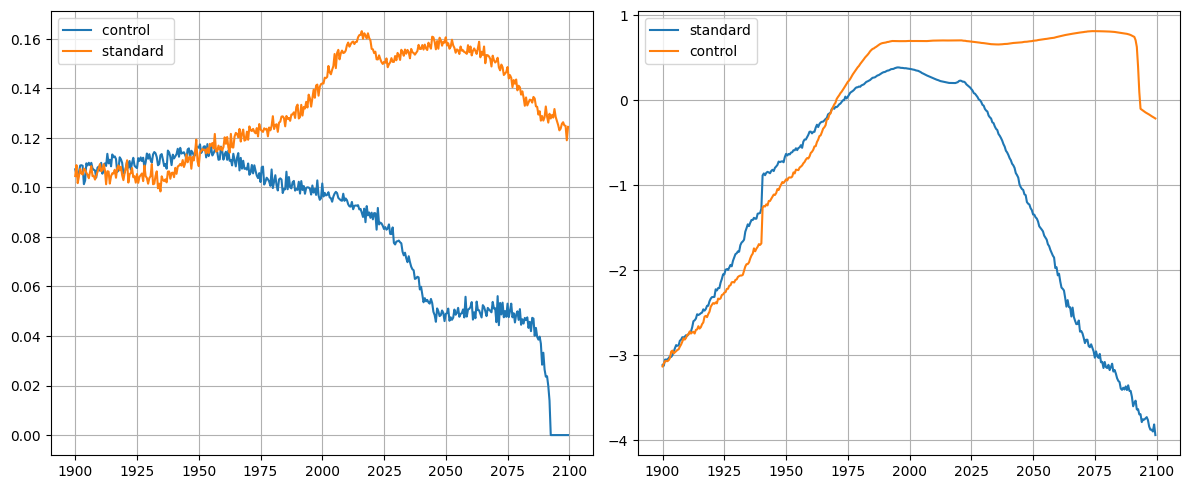

(None, <matplotlib.legend.Legend at 0x1a809b0e980>, None, None)

In [19]:
start = 0
end = -1
plt.figure(figsize=(12, 5)), plt.subplot(1, 2, 1)
plt.plot(world_control.time[start:end], world_control.fioaa[start:end], label="control ")
plt.plot(world_reference.time[start:end], world_reference.fioaa[start:end], label="standard ")
plt.grid(), plt.legend(), plt.subplot(1, 2, 2)
plt.plot(world_reference.time[start:end], reward_func(world_reference)[start:end], label="standard")
plt.plot(world_control.time[start:end], reward_func(world_control)[start:end], label="control")
plt.grid(), plt.legend(), plt.tight_layout(), plt.show()

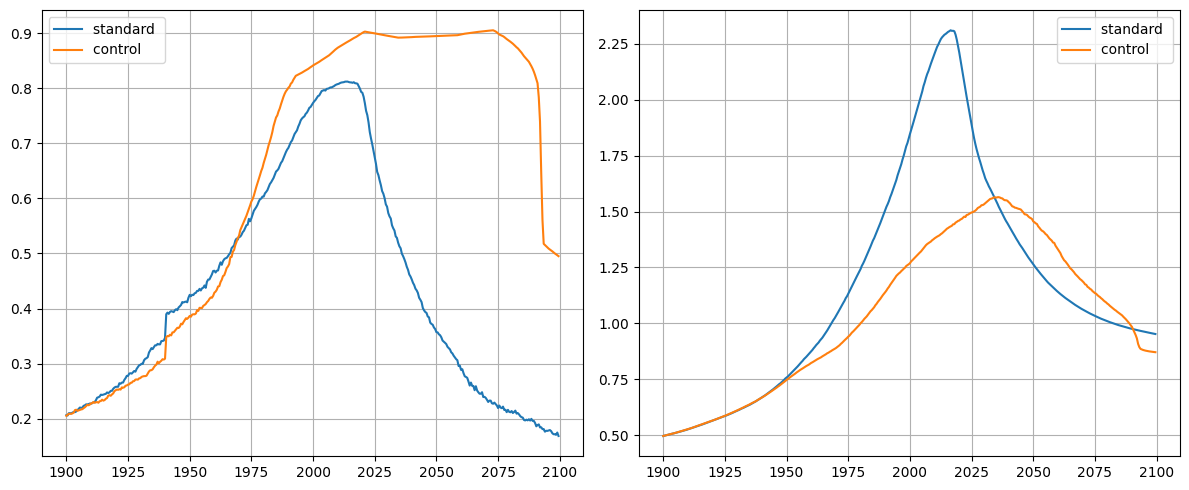

(None, <matplotlib.legend.Legend at 0x1a807723070>, None, None)

In [20]:
start = 0
end = -1

plt.figure(figsize=(12, 5)), plt.subplot(1, 2, 1)
plt.plot(world_reference.time[start:end], world_reference.hwi[start:end], label="standard ")
plt.plot(world_control.time[start:end], world_control.hwi[start:end], label="control ")
plt.grid(), plt.legend(), plt.subplot(1, 2, 2)
plt.plot(world_reference.time[start:end], world_reference.ef[start:end], label="standard ")
plt.plot(world_control.time[start:end], world_control.ef[start:end], label="control ")
plt.grid(), plt.legend(), plt.tight_layout(), plt.show()

In [21]:
def standard_run_from(world, k, fast=False):
    initial_state = {}
    for var in STATE_VARIABLES:
        if var in no_init_vars:
            continue
        val = getattr(world, var)[k]
        initial_state[var+"i"] = val

    world_temp = World3(year_max=MAX_YEAR, year_min=world.time[k], noise=NOISE)
    world_temp.set_world3_control()
    world_temp.init_world3_constants(**initial_state)
    world_temp.init_world3_variables()
    world_temp.set_world3_table_functions()
    world_temp.set_world3_noise_stds()
    world_temp.set_world3_delay_functions()
    world_temp.run_world3(fast=fast)

    J_ = J_func(reward_func(world_temp)) # this can probably be more dynamic
    return J_[0] # only want the first value

The following cell takes a while (around 25 minutes) to run when `fast=False`. But with `fast=True`, when training data included 100 runs, it took only 8 minutes.

In [22]:
time = world_control.time

J_control = J_func(reward_func(world_control)) # This can probably be more dynamic
J_standard = J_func(reward_func(world_reference))
nn_control = np.zeros((world_control.n,1))
nn_standard = np.zeros((world_reference.n,1))
standard_on_control = np.zeros((world_control.n,1))

for k in tqdm(range(0, world_control.n)):
    standard_on_control[k] = standard_run_from(world_control, k)
    nn_control[k] = nn_func(model, world_control, k)
    nn_standard[k] = nn_func(model, world_reference, k)

100%|██████████| 401/401 [07:00<00:00,  1.05s/it]


## New plots (2026)

TODO

* on/off regularisation for NN (turn on when we expect the reward to be positive)

In [23]:
def normalise_J(J_org):
    # Obtain cumulative reward divided by remaining time steps (for increased readability)
    n = np.array(J_org).shape[0]
    J_norm = np.zeros(n)
    for k in range(n):
        J_norm[k] = J_org[k, 0] / (n - k)
    return J_norm

J_control_norm = normalise_J(J_control)
J_standard_norm = normalise_J(J_standard)
nn_control_norm = normalise_J(nn_control)
nn_standard_norm = normalise_J(nn_standard)
standard_on_control_norm = normalise_J(standard_on_control)

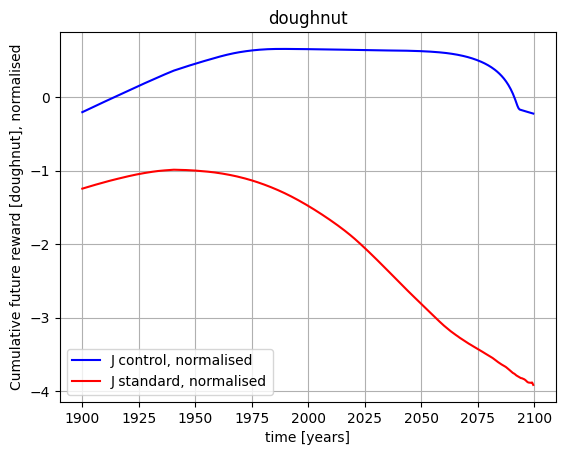

In [24]:
start = 0
end = -1

plt.plot(time[start:end], J_control_norm[start:end], 'b', label="J control, normalised")
plt.plot(time[start:end], J_standard_norm[start:end], 'r', label="J standard, normalised")
#plt.plot(time[start:end], nn_control_norm[start:end], 'b', label="nn on control, normalised", linestyle='--')
#plt.plot(time[start:end], standard_on_control_norm[start:end], 'g', label="standard run from control state, normalised", linestyle='-')
#plt.plot(time[start:end], nn_standard_norm[start:end], 'r', label="nn on standard, normalised", linestyle='--')
plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward [{reward_name}], normalised")
plt.title(f"{reward_name}")
plt.legend()
plt.grid()
#plt.savefig(f"plots/{reward_name}/J_norm")
plt.show()

## Save results

Save the results to multiple parquet files. Possibly save additional information about the RL run in JSON and/or txt file.
Save NN model also, saving the model parameters is then sufficient (see https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html).

Results to save in parquet files (one file for each item in list):
*   All state variables, time and J values (both cumulative and cumulative divided by remaining time steps) for control world throughout the whole run. Also save NN estimates of J and the controls (and their values) used. And reward function values.
*   All state variables time and J values for standard world throughout the whole run. Also save NN estimates of J. And reward function values.
*   All "standard from control" values.

Additional information to save:
*   Number of runs used to generate the training data (should be done when training data is generated, in the data generation file).
*   Exact definition of reward function (since we sometimes update constants). Should probably be done manually and saved in txt file.
*   Grid size for grid search? Can easily be done automatically.
*   Info on noise (on/off for data generation/control)?
*   RL model parameters

In [25]:
SAVE_RESULTS = True # set to False or change OUT_ID and/or CTRL_ID to not overwrite old results
OUT_ID = "33" # nn # if you load a neural net instead of building a new one, this ID should be the same as the RL ID for the nn you load
CTRL_ID = "Noise4" # control

In [26]:
# Recall: STATE_VARIABLES includes 'time'

def df_ctrl_results():
    # Save control world data
    ctrl_df = pd.DataFrame({var: getattr(world_control, var) for var in STATE_VARIABLES}) # all state variables, including time
    ctrl_df["J"] = J_control # all J values (cumulative)
    ctrl_df["Jnorm"] = J_control_norm # all J values (divided by remaining time steps)
    ctrl_df["nn"] = nn_control # all nn estimates of J
    ctrl_df["nnnorm"] = nn_control_norm # all nn estimates (divided by remaining time steps)
    ctrl_df["reward"] = reward_func(world_control) # reward (typically very quick to calculate)
    for control_name in CONTROL_NAMES:
        ctrl_df[f"{control_name}_control"] = get_control_value_list(control_name, world_control)
    return ctrl_df

def df_std_results():
    # Save standard world data
    std_df = pd.DataFrame({var: getattr(world_reference, var) for var in STATE_VARIABLES})
    std_df["J"] = J_standard
    std_df["Jnorm"] = J_standard_norm
    std_df["nn"] = nn_standard
    std_df["nnnorm"] = nn_standard_norm
    std_df["reward"] = reward_func(world_reference)
    return std_df

def df_std_ctrl():
    # Save data for standard world from control
    std_ctrl_df = pd.DataFrame({var: getattr(world_control, var) for var in STATE_VARIABLES})
    std_ctrl_df["J"] = standard_on_control
    std_ctrl_df["Jnorm"] = standard_on_control_norm
    return std_ctrl_df

def write_json_addinf_std(seed_gen_std=STD_SEED, noise=NOISE):
    # Save additional information about the standard world
        # Noise
        # Seeds (if noise is True)
    json_file_dir = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_addinf_std.json"
    json_str = "[\n"
    if noise:
        data_point = {
            "noise": noise,
            "seed_gen_std": seed_gen_std
        }
    else:
        data_point = {
            "noise": noise
        }
    json_str += json.dumps(data_point, indent=4)
    json_str += "\n]"
    json_file = os.path.join(os.getcwd(), json_file_dir)
    with open(json_file, "w") as njson:
        njson.write(json_str)

def write_json_addinf_ctrl(seed_gen_ctrl=CTRL_SEED, num_ctrl_funcs=NUM_CTRL_FUNCS, noise=NOISE, grid_sz_1=GRID_SZ_1, grid_sz_2=GRID_SZ_2, ctrl1_name=CTRL1_NAME, ctrl2_name=CTRL2_NAME, threshold=THRESHOLD, lookahead=LOOKAHEAD):
    # Save additional information in a json file:
        # Grid size
        # Noise
        # Seeds (if noise is True)
    json_file_dir = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_addinf_ctrlwrld{CTRL_ID}.json"
    json_str = "[\n"
    if num_ctrl_funcs > 1:
        if noise:
            data_point = {
                "num_ctrl_funcs": num_ctrl_funcs,
                "ctrl1": ctrl1_name,
                "ctrl2": ctrl2_name,
                "grid_size_1": grid_sz_1,
                "grid_size_2": grid_sz_2,
                "noise": noise,
                "seed_gen_ctrl": seed_gen_ctrl,
                "threshold": threshold,
                "lookahead": lookahead
            }
        else:
            data_point = {
                "num_ctrl_funcs": num_ctrl_funcs,
                "ctrl1": ctrl1_name,
                "ctrl2": ctrl2_name,
                "grid_size_1": grid_sz_1,
                "grid_size_2": grid_sz_2,
                "noise": noise,
                "threshold": threshold,
                "lookahead": lookahead
            }
    else:
        if noise:
            data_point = {
                "num_ctrl_funcs": num_ctrl_funcs,
                "ctrl1": ctrl1_name,
                "grid_size_1": grid_sz_1,
                "noise": noise,
                "seed_gen_ctrl": seed_gen_ctrl,
                "threshold": threshold,
                "lookahead": lookahead
            }
        else:
            data_point = {
                "num_ctrl_funcs": num_ctrl_funcs,
                "ctrl1": ctrl1_name,
                "grid_size_1": grid_sz_1,
                "noise": noise,
                "threshold": threshold,
                "lookahead": lookahead
            }
    json_str += json.dumps(data_point, indent=4)
    json_str += "\n]"
    json_file = os.path.join(os.getcwd(), json_file_dir)
    with open(json_file, "w") as njson:
        njson.write(json_str)

def save_rl_params(mdl=model):
    # https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html#example
    filepath = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_model.pt"
    torch.save(mdl.state_dict(), filepath)

def save_normalisers():

    # X_normaliser
    x_path = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_xnormaliser.pkl"
    with open(x_path, 'wb') as fid: # https://stackoverflow.com/questions/10592605/save-classifier-to-disk-in-scikit-learn
        pickle.dump(X_normaliser, fid)

    # J_normaliser
    j_path = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_jnormaliser.pkl"
    with open(j_path, 'wb') as fid:
        pickle.dump(J_normaliser, fid)

def write_json_addinf_nn(in_dim=X_train.shape[1]):
    json_file_dir = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_addinf_nn.json"
    json_str = "[\n"
    data_point = {"nn_in_dim": in_dim}
    json_str += json.dumps(data_point, indent=4)
    json_str += "\n]"
    json_file = os.path.join(os.getcwd(), json_file_dir)
    with open(json_file, "w") as njson:
        njson.write(json_str)

def save_results(ctrl=True, std=True, std_ctrl=True, addinf_std=True, addinf_ctrl=True, nn_model=True):
    
    if ctrl:
        ctrl_df = df_ctrl_results()
        ctrl_path = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_control_world{CTRL_ID}.parquet"
        ctrl_df.to_parquet(ctrl_path)

    if std:
        std_df = df_std_results()
        std_path = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_standard_world.parquet"
        std_df.to_parquet(std_path)

    if std_ctrl:
        std_ctrl_df = df_std_ctrl()
        std_ctrl_path = f"datasets/ctrl_results/{reward_name}/train{IN_ID}_rl{OUT_ID}_standard_from_control{CTRL_ID}.parquet"
        std_ctrl_df.to_parquet(std_ctrl_path)
    
    if addinf_std:
        write_json_addinf_std()

    if addinf_ctrl:
        write_json_addinf_ctrl()
    
    if nn_model:
        save_rl_params()
        save_normalisers()
        write_json_addinf_nn()

if SAVE_RESULTS:
    if LOAD_NN_TRAIN_ID!=None and LOAD_NN_RL_ID!=None:
        save_results(nn_model=False)
    else:
        save_results()

## Plot results (plots selected by last year's students, keep for comparison)

[]

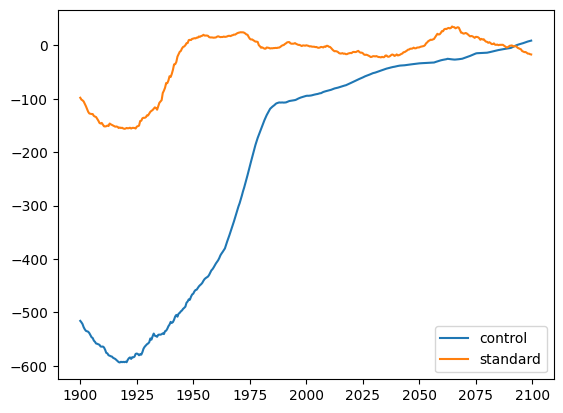

In [27]:
start = 0
end = -1

plt.plot(time[start:end], nn_control[start:end]-J_control[start:end], label='control')
plt.plot(time[start:end], nn_standard[start:end]-J_standard[start:end], label='standard')
plt.legend()
plt.plot()

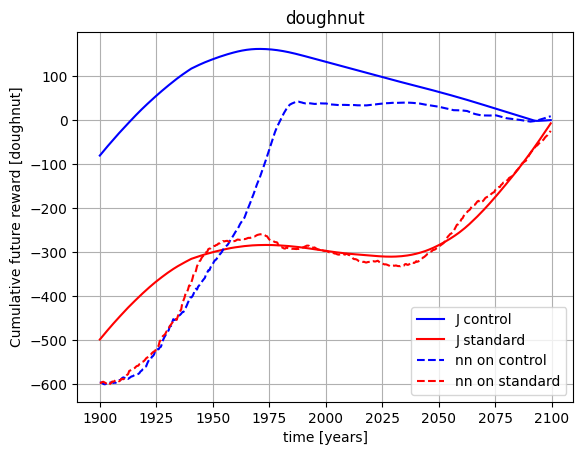

In [28]:
start = 0
end = -1

plt.plot(time[start:end], J_control[start:end], 'b', label="J control")
plt.plot(time[start:end], J_standard[start:end], 'r', label="J standard")
plt.plot(time[start:end], nn_control[start:end], 'b', label="nn on control", linestyle='--')
#plt.plot(time[start:end], standard_on_control[start:end], 'g', label="standard run from control state", linestyle='-')
plt.plot(time[start:end], nn_standard[start:end], 'r', label="nn on standard", linestyle='--')
plt.xlabel("time [years]")
plt.ylabel(f"Cumulative future reward [{reward_name}]")
plt.title(f"{reward_name}")
plt.legend()
plt.grid()
plt.savefig(f"plots/{reward_name}/J")
plt.show()

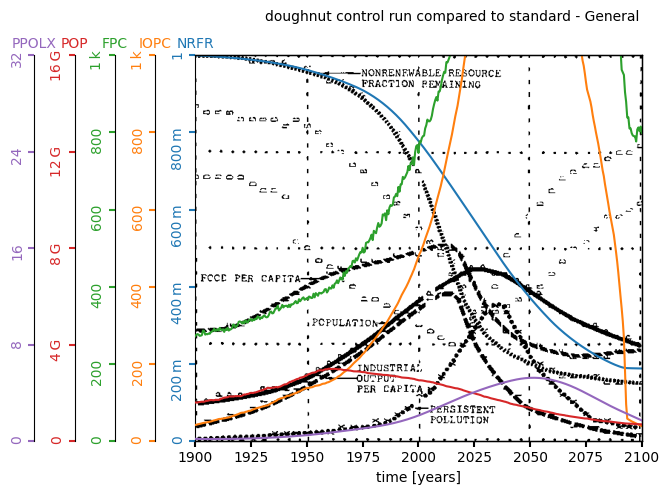

In [29]:
from pyworld3.utils import plot_world_variables
plot_world_variables(
    world_control.time,
    [world_control.nrfr, world_control.iopc, world_control.fpc, world_control.pop, world_control.ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    img_background="./img/fig7-7.png",
    figsize=(7, 5),
    title=f"{reward_name} control run compared to standard - General",
)
#plt.savefig(f"plots/{reward_name}/general")
plt.show()

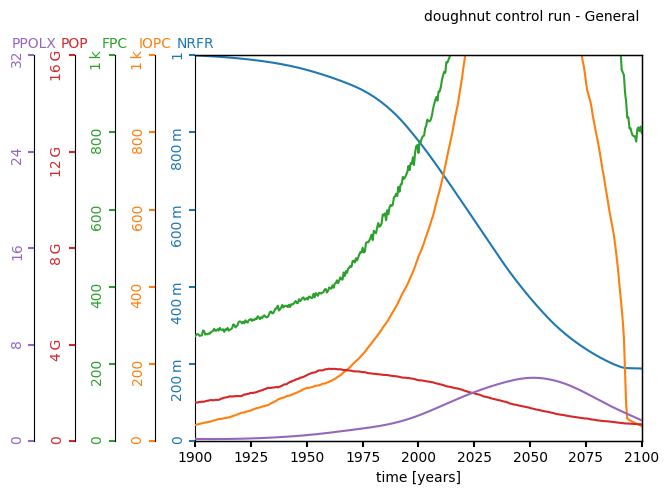

In [30]:
plot_world_variables(
    world_control.time,
    [world_control.nrfr, world_control.iopc, world_control.fpc, world_control.pop, world_control.ppolx],
    ["NRFR", "IOPC", "FPC", "POP", "PPOLX"],
    [[0, 1], [0, 1e3], [0, 1e3], [0, 16e9], [0, 32]],
    figsize=(7, 5),
    title=f"{reward_name} control run - General",
)
plt.savefig(f"plots/{reward_name}/general_nobackground")
plt.show()

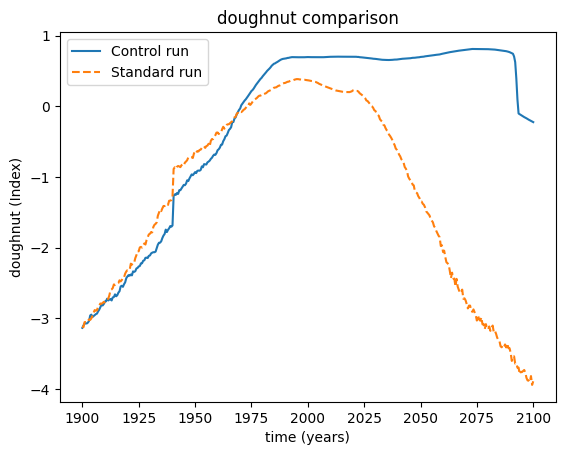

In [31]:
plt.plot(time, reward_func(world_control), label="Control run")
plt.plot(time, reward_func(world_reference), label="Standard run", linestyle='--')
plt.xlabel("time (years)")
plt.legend()
plt.ylabel(f"{reward_name} (Index)")
plt.title(f"{reward_name} comparison")
plt.savefig(f"plots/{reward_name}/comparison")

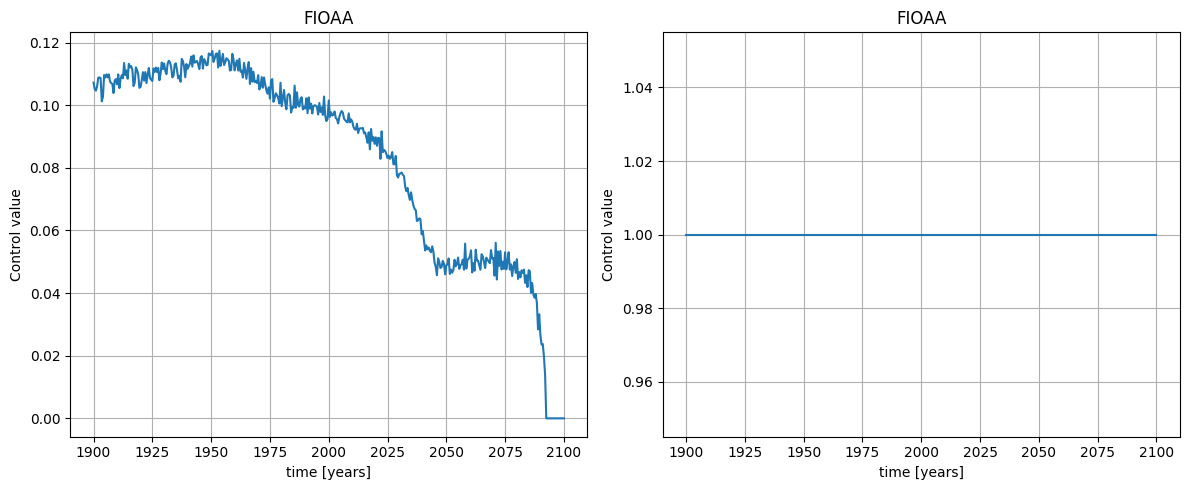

In [32]:
plt.figure(figsize=(12, 5)), plt.subplot(1, 2, 1)
#plt.plot(world_reference.time[start:end], world_reference.fioac[start:end], label="standard fioac")
plt.plot(world_control.time, world_control.fioaa)
#plt.plot(world_control.time[start:end], world_control.nr[start:end], label="control isopc")
plt.grid(), 
plt.ylabel("Control value"), 
plt.xlabel("time [years]") 
plt.title("FIOAA")
plt.tight_layout()
plt.subplot(1, 2, 2)

plt.plot(world_reference.time, world_control.fioaa_control_values)
#plt.plot(world_control.time, world_control.fioaa)
#plt.plot(world_reference.time[start:end], world_reference.ppol[start:end], label="standard")
#plt.plot(world_control.time[start:end], world_control.ppol[start:end], label="control")
plt.grid(), 
plt.ylabel("Control value"), 
plt.xlabel("time [years]") 
plt.title("FIOAA")
plt.tight_layout(),
plt.savefig(f"plots/{reward_name}/controls")
plt.show()

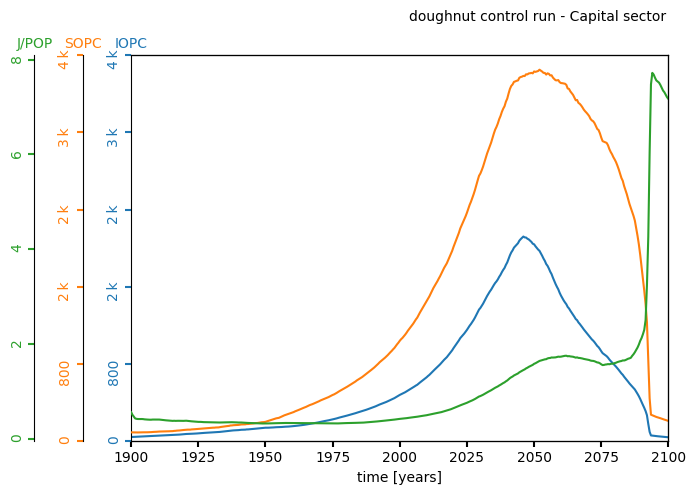

In [33]:
plot_world_variables(
    world_control.time,
    [
        world_control.iopc,
        world_control.sopc,
        world_control.j / world_control.pop
    ],
    ["IOPC", "SOPC", "J/POP"],
    [[0, 4e3], [0, 4e3]],
    #img_background="./img/fig7-8.png",
    figsize=(7, 5),
    title=f"{reward_name} control run - Capital sector",
)
plt.savefig(f"plots/{reward_name}/capital_sector")

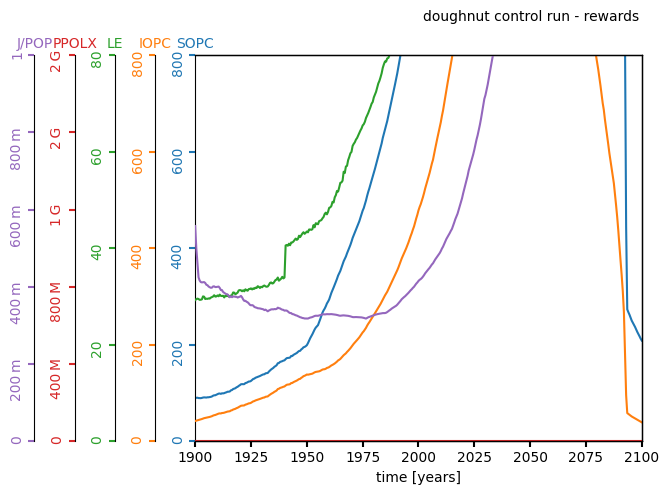

In [34]:
plot_world_variables( # Dint think we need this one
    world_control.time,
    [world_control.sopc, world_control.iopc, world_control.le, world_control.ppolx, world_control.j/world_control.pop],
    ["SOPC", "IOPC", "LE", "PPOLX", "J/POP"],
    [[0, 8e2], [0, 8e2], [0,80], [0,2e9], [0,1]],
    figsize=(7, 5),
    title=f"{reward_name} control run - rewards",
)